# Image + Text Fusion — Recommendation Retrieval Prototype



In [1]:
# ============================================================
# 1. INSTALL + IMPORTS
# ============================================================

!pip -q install torch torchvision sentence-transformers pandas numpy matplotlib pillow scikit-learn spacy
!python -m spacy download en_core_web_sm -q

import os
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
from sentence_transformers import SentenceTransformer
import spacy
from collections import Counter

warnings.filterwarnings("ignore")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 53.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Device: cpu


In [10]:
# ============================================================
# 2. CONFIG
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

DATASET_ROOT = "/content/drive/MyDrive/SoftCom Project/Dataset"

IMAGE_EMBEDDINGS_PATH = os.path.join(DATASET_ROOT, "Baseline_Results/DINOv2", "dinov2_embeddings_dinov2_vits14.npz")
TEXT_EMBEDDINGS_PATH  = os.path.join(DATASET_ROOT, "Text_Metadata_Results", "caption_embeddings_labse.npz")
METADATA_PATH         = os.path.join(DATASET_ROOT, "Text_Metadata_Results", "metadata_with_event_tags.csv")
RAW_IMAGES_FOLDER      = "/content/drive/MyDrive/Wall decoration images"

OUTPUT_FOLDER = os.path.join(DATASET_ROOT, "Fusion_Retrieval_Results")
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

DINOV2_MODEL_NAME = "dinov2_vits14"   # must match what dinov2_baseline.ipynb used
TEXT_MODEL_NAME = "sentence-transformers/LaBSE"

IMAGE_SIZE = (224, 224)
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

COLOR_MODEL_FOLDER = os.path.join(DATASET_ROOT, "Baseline_Results_ColorPalette")
COLOR_MODEL_INFO_PATH = os.path.join(COLOR_MODEL_FOLDER, "color_model_info.json")

CONVNEXT_MODEL_FOLDER = os.path.join(DATASET_ROOT, "Baseline_Results/ConvNeXt-Tiny")
CONVNEXT_MODEL_INFO_PATH = os.path.join(CONVNEXT_MODEL_FOLDER, "convnext_model_info.json")
CONVNEXT_VARIANT_FOR_LIVE_PREDICTION = "tiny"   # must match what convnext_tiny_baseline.ipynb used


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load cached embeddings + metadata

In [11]:
# ============================================================
# 3. LOAD CACHED EMBEDDINGS + METADATA
# ============================================================

image_cache = np.load(IMAGE_EMBEDDINGS_PATH, allow_pickle=True)
text_cache  = np.load(TEXT_EMBEDDINGS_PATH, allow_pickle=True)

image_ids_img = list(image_cache["image_ids"])
image_ids_txt = list(text_cache["image_ids"])

# keep only images present in BOTH caches, same order
common_ids = [iid for iid in image_ids_img if iid in set(image_ids_txt)]
print(f"Images with both embeddings: {len(common_ids)} / img_cache={len(image_ids_img)} / text_cache={len(image_ids_txt)}")

img_idx = {iid: i for i, iid in enumerate(image_ids_img)}
txt_idx = {iid: i for i, iid in enumerate(image_ids_txt)}

image_matrix = np.stack([image_cache["embeddings"][img_idx[iid]] for iid in common_ids])
text_matrix  = np.stack([text_cache["embeddings"][txt_idx[iid]] for iid in common_ids])

# L2-normalize both -- LaBSE embeddings were already normalized at extraction time, but
# DINOv2's raw CLS token is not guaranteed unit norm, so normalize here for a fair combination.
def l2_normalize(matrix):
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    return matrix / np.maximum(norms, 1e-8)

image_matrix = l2_normalize(image_matrix)
text_matrix  = l2_normalize(text_matrix)

metadata_df = pd.read_csv(METADATA_PATH, encoding="utf-8-sig")
metadata_df = metadata_df.set_index("image_id").loc[common_ids].reset_index()

print("image_matrix:", image_matrix.shape, "| text_matrix:", text_matrix.shape)

# ------------------------------------------------------------------
# Ground-truth color matrix (for dataset images -- they're already annotated,
# so no prediction needed here, only for a brand-new query image later)
import json as json_lib
from sklearn.preprocessing import MultiLabelBinarizer

with open(COLOR_MODEL_INFO_PATH) as f:
    color_model_info = json_lib.load(f)
MODELED_COLORS = color_model_info["modeled_colors"]

def parse_colors(value):
    colors = [c.strip().lower() for c in str(value).split(",") if c.strip()]
    return [c for c in colors if c in MODELED_COLORS]

metadata_df["color_list"] = metadata_df["color_idea"].apply(parse_colors)
color_mlb = MultiLabelBinarizer(classes=MODELED_COLORS)
color_matrix = color_mlb.fit_transform(metadata_df["color_list"]).astype(float)
print(f"Ground-truth color matrix: {color_matrix.shape} (modeled colors: {MODELED_COLORS})")


Images with both embeddings: 288 / img_cache=288 / text_cache=288
image_matrix: (288, 384) | text_matrix: (288, 768)
Ground-truth color matrix: (288, 11) (modeled colors: ['black', 'blue', 'brown', 'gold', 'green', 'orange', 'pink', 'purple', 'red', 'white', 'yellow'])


In [12]:
# ============================================================
# 4. COMBINED SIMILARITY RETRIEVAL (image + text + color)
# ============================================================

def retrieve_top_k(query_idx, w_image, w_text, w_color=0.0, top_k=5, exclude_self=True):
    image_sims = image_matrix @ image_matrix[query_idx]
    text_sims  = text_matrix  @ text_matrix[query_idx]
    # Jaccard-style color agreement using the query's OWN ground-truth colors (dataset-internal only)
    query_colors = color_matrix[query_idx]
    intersection = (color_matrix * query_colors).sum(axis=1)
    union = np.clip(color_matrix + query_colors, 0, 1).sum(axis=1)
    color_sims = np.divide(intersection, union, out=np.zeros_like(intersection), where=union > 0)

    combined = w_image * image_sims + w_text * text_sims + w_color * color_sims

    order = np.argsort(-combined)
    if exclude_self:
        order = order[order != query_idx]
    return order[:top_k], combined[order[:top_k]]


def show_retrieval(query_idx, w_image, w_text, w_color=0.0, top_k=5):
    query_row = metadata_df.iloc[query_idx]
    print(f"QUERY: {query_row['image_id']} | wall_type={query_row['wall_type']} | "
          f"event={query_row.get('event_type_inferred', '?')} | colors={query_row['color_idea']}")
    top_idx, scores = retrieve_top_k(query_idx, w_image, w_text, w_color, top_k)
    for idx, score in zip(top_idx, scores):
        row = metadata_df.iloc[idx]
        print(f"  [{score:.3f}] {row['image_id']} | wall_type={row['wall_type']} | "
              f"event={row.get('event_type_inferred', '?')} | colors={row['color_idea']}")

print("=== image only ===")
show_retrieval(0, w_image=1.0, w_text=0.0, w_color=0.0)
print("\n=== text/event only ===")
show_retrieval(0, w_image=0.0, w_text=1.0, w_color=0.0)
print("\n=== fused (image+text+color) ===")
show_retrieval(0, w_image=0.4, w_text=0.4, w_color=0.2)


=== image only ===
QUERY: image_001 | wall_type=brick_wall | event=sports | colors=black,white
  [0.642] image_010 | wall_type=brick_wall | event=sports | colors=black,white,green,yellow
  [0.629] image_255 | wall_type=brick_wall | event=sports | colors=red, black, white
  [0.588] image_211 | wall_type=brick_wall | event=tech_academic | colors=black, turquoise, white, brown
  [0.570] image_086 | wall_type=brick_wall | event=sports | colors=red, blue, yellow, orange, white
  [0.539] image_222 | wall_type=brick_wall | event=tech_academic | colors=red, white, teal, brown

=== text/event only ===
QUERY: image_001 | wall_type=brick_wall | event=sports | colors=black,white
  [0.804] image_161 | wall_type=brick_wall | event=sports | colors=maroon, black, white, blue
  [0.782] image_162 | wall_type=brick_wall | event=sports | colors=yellow, black, red, green, purple
  [0.774] image_002 | wall_type=brick_wall | event=sports | colors=black,white,gold
  [0.680] image_169 | wall_type=painted_wall 

In [13]:
# ============================================================
# 5. WEIGHT SWEEP -- AGREEMENT WITH wall_type / event_type
# ============================================================

primary_event = metadata_df["event_type_inferred"].apply(lambda t: str(t).split(",")[0])

def evaluate_weights(w_image, w_text, w_color, top_k=5):
    wall_type_hits, event_hits = [], []
    for query_idx in range(len(metadata_df)):
        top_idx, _ = retrieve_top_k(query_idx, w_image, w_text, w_color, top_k)
        query_wall = metadata_df.iloc[query_idx]["wall_type"]
        query_event = primary_event.iloc[query_idx]

        neighbor_walls = metadata_df.iloc[top_idx]["wall_type"].values
        neighbor_events = primary_event.iloc[top_idx].values

        wall_type_hits.append(np.mean(neighbor_walls == query_wall))
        event_hits.append(np.mean(neighbor_events == query_event))
    return np.mean(wall_type_hits), np.mean(event_hits)

# Sweep the image/text split at a few fixed color weights
weight_configs = []
for w_color in [0.0, 0.2, 0.4]:
    remaining = 1.0 - w_color
    for split in [0.0, 0.25, 0.5, 0.75, 1.0]:
        weight_configs.append((split * remaining, (1 - split) * remaining, w_color))

sweep_results = []
for w_image, w_text, w_color in weight_configs:
    wall_agreement, event_agreement = evaluate_weights(w_image, w_text, w_color)
    sweep_results.append({"w_image": w_image, "w_text": w_text, "w_color": w_color,
                           "wall_type_agreement@5": wall_agreement, "event_type_agreement@5": event_agreement})
    print(f"w_image={w_image:.2f} w_text={w_text:.2f} w_color={w_color:.2f}  "
          f"wall_type_agreement@5={wall_agreement:.3f}  event_type_agreement@5={event_agreement:.3f}")

sweep_df = pd.DataFrame(sweep_results)
sweep_df["combined_agreement"] = sweep_df["wall_type_agreement@5"] + sweep_df["event_type_agreement@5"]
sweep_df.to_csv(os.path.join(OUTPUT_FOLDER, "weight_sweep_results.csv"), index=False)
display(sweep_df.sort_values("combined_agreement", ascending=False).head(10))

best_row = sweep_df.loc[sweep_df["combined_agreement"].idxmax()]
BEST_W_IMAGE, BEST_W_TEXT, BEST_W_COLOR = best_row["w_image"], best_row["w_text"], best_row["w_color"]
print(f"\nBest weights: w_image={BEST_W_IMAGE:.2f} w_text={BEST_W_TEXT:.2f} w_color={BEST_W_COLOR:.2f}")


w_image=0.00 w_text=1.00 w_color=0.00  wall_type_agreement@5=0.499  event_type_agreement@5=0.601
w_image=0.25 w_text=0.75 w_color=0.00  wall_type_agreement@5=0.551  event_type_agreement@5=0.593
w_image=0.50 w_text=0.50 w_color=0.00  wall_type_agreement@5=0.548  event_type_agreement@5=0.556
w_image=0.75 w_text=0.25 w_color=0.00  wall_type_agreement@5=0.544  event_type_agreement@5=0.503
w_image=1.00 w_text=0.00 w_color=0.00  wall_type_agreement@5=0.524  event_type_agreement@5=0.422
w_image=0.00 w_text=0.80 w_color=0.20  wall_type_agreement@5=0.491  event_type_agreement@5=0.551
w_image=0.20 w_text=0.60 w_color=0.20  wall_type_agreement@5=0.504  event_type_agreement@5=0.557
w_image=0.40 w_text=0.40 w_color=0.20  wall_type_agreement@5=0.533  event_type_agreement@5=0.527
w_image=0.60 w_text=0.20 w_color=0.20  wall_type_agreement@5=0.533  event_type_agreement@5=0.488
w_image=0.80 w_text=0.00 w_color=0.20  wall_type_agreement@5=0.524  event_type_agreement@5=0.417
w_image=0.00 w_text=0.60 w_col

,w_image,w_text,w_color,wall_type_agreement@5,event_type_agreement@5,combined_agreement
1,0.25,0.75,0.0,0.550694,0.593056,1.143750
2,0.50,0.50,0.0,0.547917,0.556250,1.104167
0,0.00,1.00,0.0,0.498611,0.601389,1.100000
6,0.20,0.60,0.2,0.504167,0.556944,1.061111
7,0.40,0.40,0.2,0.533333,0.527083,1.060417
3,0.75,0.25,0.0,0.543750,0.502778,1.046528
5,0.00,0.80,0.2,0.490972,0.550694,1.041667
8,0.60,0.20,0.2,0.532639,0.487500,1.020139
4,1.00,0.00,0.0,0.524306,0.422222,0.946528
9,0.80,0.00,0.2,0.524306,0.417361,0.941667



Best weights: w_image=0.25 w_text=0.75 w_color=0.00


In [14]:
# ============================================================
# 6. LOAD MODELS FOR LIVE QUERIES
# ============================================================

dinov2_model = torch.hub.load("facebookresearch/dinov2", DINOV2_MODEL_NAME).to(DEVICE).eval()
text_model = SentenceTransformer(TEXT_MODEL_NAME, device=DEVICE)

eval_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


@torch.no_grad()
def embed_new_image(image_path):
    with Image.open(image_path) as img:
        image = img.convert("RGB")
    tensor = eval_transform(image).unsqueeze(0).to(DEVICE)
    feats = dinov2_model.forward_features(tensor)["x_norm_clstoken"]
    vec = feats.cpu().numpy().flatten()
    return vec / max(np.linalg.norm(vec), 1e-8)


def embed_new_text(text):
    return text_model.encode([text], normalize_embeddings=True)[0]


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [15]:
# ============================================================
# 6b. LOAD TRAINED COLOR MODEL (from color_baseline.ipynb) + PREDICTION FUNCTION
# ============================================================

if color_model_info["method"] == "linear_head":
    color_head = nn.Linear(color_model_info["embed_dim"], len(MODELED_COLORS)).to(DEVICE)
    color_head.load_state_dict(torch.load(os.path.join(COLOR_MODEL_FOLDER, "color_linear_head.pt"), map_location=DEVICE))
    color_head.eval()

    @torch.no_grad()
    def predict_color_vector(image_embedding):
        x = torch.tensor(image_embedding, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        probs = torch.sigmoid(color_head(x)).cpu().numpy().flatten()
        return (probs >= 0.5).astype(float)
else:
    import joblib
    color_clf = joblib.load(os.path.join(COLOR_MODEL_FOLDER, "color_ovr_logreg.joblib"))

    def predict_color_vector(image_embedding):
        return color_clf.predict(image_embedding.reshape(1, -1)).flatten().astype(float)

print(f"Loaded color model ({color_model_info['method']}) for {len(MODELED_COLORS)} colors: {MODELED_COLORS}")


Loaded color model (linear_head) for 11 colors: ['black', 'blue', 'brown', 'gold', 'green', 'orange', 'pink', 'purple', 'red', 'white', 'yellow']


In [16]:
# ============================================================
# 6c. RECOMMEND -- new image + event text -> top-k similar past decorations
# ============================================================

def recommend(new_image_path, event_text, w_image=BEST_W_IMAGE, w_text=BEST_W_TEXT,
              w_color=BEST_W_COLOR, top_k=5):
    query_image_vec = embed_new_image(new_image_path)
    query_text_vec = embed_new_text(event_text)
    predicted_colors_vec = predict_color_vector(query_image_vec)
    predicted_colors = [c for c, present in zip(MODELED_COLORS, predicted_colors_vec) if present]
    print(f"Predicted color palette for query image: {predicted_colors}")

    image_sims = image_matrix @ query_image_vec
    text_sims  = text_matrix  @ query_text_vec
    intersection = (color_matrix * predicted_colors_vec).sum(axis=1)
    union = np.clip(color_matrix + predicted_colors_vec, 0, 1).sum(axis=1)
    color_sims = np.divide(intersection, union, out=np.zeros_like(intersection), where=union > 0)

    combined = w_image * image_sims + w_text * text_sims + w_color * color_sims

    top_idx = np.argsort(-combined)[:top_k]
    recommendations = metadata_df.iloc[top_idx].copy()
    recommendations["similarity_score"] = combined[top_idx]
    return recommendations[["image_id", "wall_type", "indoor", "color_idea",
                             "event_type_inferred", "similarity_score"]]


In [17]:
# ============================================================
# 6d. LOAD CONVNEXT WALL_TYPE + INDOOR MODELS FOR LIVE PREDICTION
# ============================================================

from torchvision import models as tv_models

with open(CONVNEXT_MODEL_INFO_PATH) as f:
    convnext_model_info = json_lib.load(f)
WALL_TYPE_CLASSES = convnext_model_info["wall_type_classes"]

def build_convnext_classifier(variant, num_classes):
    builders = {
        "tiny": tv_models.convnext_tiny, "small": tv_models.convnext_small,
        "base": tv_models.convnext_base, "large": tv_models.convnext_large,
    }
    model = builders[variant](weights=None)  # weights loaded from checkpoint below
    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Linear(in_features, num_classes)
    return model

wall_type_model = build_convnext_classifier(CONVNEXT_VARIANT_FOR_LIVE_PREDICTION, convnext_model_info["num_classes"]["wall_type"])
wall_type_model.load_state_dict(torch.load(
    os.path.join(CONVNEXT_MODEL_FOLDER, f"finetuned_convnext_{CONVNEXT_VARIANT_FOR_LIVE_PREDICTION}_wall_type.pt"),
    map_location=DEVICE))
wall_type_model = wall_type_model.to(DEVICE).eval()

indoor_model = build_convnext_classifier(CONVNEXT_VARIANT_FOR_LIVE_PREDICTION, convnext_model_info["num_classes"]["indoor"])
indoor_model.load_state_dict(torch.load(
    os.path.join(CONVNEXT_MODEL_FOLDER, f"finetuned_convnext_{CONVNEXT_VARIANT_FOR_LIVE_PREDICTION}_indoor.pt"),
    map_location=DEVICE))
indoor_model = indoor_model.to(DEVICE).eval()


@torch.no_grad()
def predict_wall_type_and_indoor(image_path):
    with Image.open(image_path) as img:
        image = img.convert("RGB")
    tensor = eval_transform(image).unsqueeze(0).to(DEVICE)

    wall_type_idx = wall_type_model(tensor).argmax(dim=1).item()
    indoor_idx = indoor_model(tensor).argmax(dim=1).item()

    return WALL_TYPE_CLASSES[wall_type_idx], ("indoor" if indoor_idx == 1 else "outdoor")

print(f"Loaded wall_type classifier ({len(WALL_TYPE_CLASSES)} classes: {WALL_TYPE_CLASSES}) and indoor classifier.")


Loaded wall_type classifier (5 classes: ['backdrop_board', 'brick_wall', 'bulletin_board', 'painted_wall', 'wooden_wall']) and indoor classifier.


In [18]:
# ============================================================
# 6e. STYLE + ELEMENTS EXTRACTION (from retrieved captions)
# ============================================================

nlp = spacy.load("en_core_web_sm")

GENERIC_WORDS = {
    "wall", "campus", "decoration", "image", "photo", "picture", "university", "college",
    "building", "background", "area", "section", "aust", "student", "students",
}

def extract_style_and_elements(captions, top_n_elements=6, top_n_style=3):
    combined_text = " ".join(captions)
    doc = nlp(combined_text.lower())

    nouns = [tok.lemma_ for tok in doc if tok.pos_ in ("NOUN", "PROPN") and tok.lemma_ not in GENERIC_WORDS and tok.is_alpha]
    adjectives = [tok.lemma_ for tok in doc if tok.pos_ == "ADJ" and tok.lemma_ not in GENERIC_WORDS and tok.is_alpha]

    top_elements = [word for word, _ in Counter(nouns).most_common(top_n_elements)]
    top_style_words = [word for word, _ in Counter(adjectives).most_common(top_n_style)]
    return top_elements, top_style_words


In [19]:
# ============================================================
# 6f. RECOMMENDATION SENTENCE GENERATOR (template-based)
# ============================================================

import random

SENTENCE_TEMPLATES = [
    "Use a {color1}-{color2} {style} theme with a central {element1}/{element2} motif, "
    "incorporating {element3} for added detail -- well suited to your {environment} {wall} wall.",

    "For this {event}, consider a {style} look built around {color1} and {color2}, anchored by "
    "{element1} and {element2} imagery, with {element3} as a supporting accent.",

    "A {color1}, {color2} and {color3} palette works well here -- build the design around a "
    "{element1}/{element2} centerpiece, styled to feel {style}.",
]

def generate_recommendation_sentence(plan):
    colors = [c.strip() for c in plan["Color palette"].split(",") if c.strip()]
    elements = [e.strip() for e in plan["Elements"].split(",") if e.strip()]
    style_words = [s.strip() for s in plan["Style"].split(",") if s.strip()]

    # Pad with safe fallbacks if there weren't enough distinct colors/elements/style words
    colors = (colors + ["neutral", "white", "grey"])[:3]
    elements = (elements + ["a decorative motif", "supporting graphics", "an accent piece"])[:3]
    style = style_words[0] if style_words else "themed"

    wall_type, environment = plan["Wall"].rsplit("(", 1)
    environment = environment.rstrip(")").strip()

    template = random.choice(SENTENCE_TEMPLATES)
    sentence = template.format(
        color1=colors[0].lower(), color2=colors[1].lower(), color3=colors[2].lower(),
        element1=elements[0].lower(), element2=elements[1].lower(), element3=elements[2].lower(),
        style=style.lower(), environment=environment.lower(), wall=wall_type.strip().lower(),
        event=plan["Event"].lower(),
    )
    return sentence[0].upper() + sentence[1:]


In [20]:
# ============================================================
# 6f. GENERATE DECORATION PLAN
# ============================================================

def generate_decoration_plan(new_image_path, event_text, w_image=BEST_W_IMAGE, w_text=BEST_W_TEXT,
                              w_color=BEST_W_COLOR, top_k=5):
    # --- retrieval (reuses the existing fusion scoring) ---
    recommendations = recommend(new_image_path, event_text, w_image, w_text, w_color, top_k)

    # --- wall_type / indoor for the query ---
    predicted_wall_type, predicted_indoor = predict_wall_type_and_indoor(new_image_path)

    # --- color palette for the query (reuses the already-loaded color model) ---
    query_image_vec = embed_new_image(new_image_path)
    predicted_colors_vec = predict_color_vector(query_image_vec)
    predicted_colors = [c for c, present in zip(MODELED_COLORS, predicted_colors_vec) if present]

    # --- style + elements from the retrieved neighbors' captions ---
    neighbor_captions = metadata_df.set_index("image_id").loc[recommendations["image_id"], "description_en"].tolist() \
        if "description_en" in metadata_df.columns else []
    if not neighbor_captions:
        # metadata_with_event_tags.csv may not carry description_en -- fall back to full_metadata if needed
        neighbor_captions = [""]
    elements, style_words = extract_style_and_elements(neighbor_captions)

    dominant_event = recommendations["event_type_inferred"].apply(lambda t: str(t).split(",")[0]).mode()
    dominant_event = dominant_event.iloc[0] if len(dominant_event) else "general"

    style_phrase = ", ".join([dominant_event.replace("_", " ")] + style_words)

    plan = {
        "Event": event_text.title(),
        "Wall": f"{predicted_wall_type.replace('_', ' ').title()} ({predicted_indoor})",
        "Color palette": ", ".join(c.title() for c in predicted_colors) if predicted_colors else "Not enough signal",
        "Style": style_phrase.title(),
        "Elements": ", ".join(e.title() for e in elements) if elements else "Not enough signal",
        "Reference examples": ", ".join(recommendations["image_id"].tolist()),
    }

    recommendation_sentence = generate_recommendation_sentence(plan)
    plan["Recommendation"] = recommendation_sentence

    print("Recommended Decoration Plan")
    for key, value in plan.items():
        if key == "Recommendation":
            continue
        print(f"{key}: {value}")
    print(f"\nRECOMMENDATION\n\"{recommendation_sentence}\"")

    return plan, recommendations


In [21]:
# ============================================================
# 7. DEMO QUERY -- sanity check (existing dataset image, no user input)
# ============================================================

NEW_IMAGE_PATH = glob.glob(os.path.join(RAW_IMAGES_FOLDER, "image_001.*"))[0]
EVENT_TEXT = "decoration for a cricket tournament celebration"

plan, recommendations = generate_decoration_plan(NEW_IMAGE_PATH, EVENT_TEXT, top_k=5)


Predicted color palette for query image: ['black', 'brown', 'red', 'white']
Recommended Decoration Plan
Event: Decoration For A Cricket Tournament Celebration
Wall: Brick Wall (indoor)
Color palette: Black, Brown, Red, White
Style: Sports, Celebratory, Congratulatory, Colored
Elements: Cricket, Team, Graphic, Sport, Ball, Trophy
Reference examples: image_001, image_161, image_162, image_142, image_010

RECOMMENDATION
"Use a black-brown sports theme with a central cricket/team motif, incorporating graphic for added detail -- well suited to your indoor brick wall wall."


Upload a photo of the wall you want decoration ideas for:


Saving space-3197611_640.jpg to space-3197611_640.jpg

Describe the event (e.g. 'Pohela Boishakh celebration', 'cricket tournament'): sports day
Predicted color palette for query image: ['black', 'brown', 'orange', 'purple', 'red', 'white']
Recommended Decoration Plan
Event: Sports Day
Wall: Brick Wall (indoor)
Color palette: Black, Brown, Orange, Purple, Red, White
Style: Sports, Colorful, Olympic, Various
Elements: Sport, Day, Cutout, Display, Board, Backdrop
Reference examples: image_090, image_082, image_115, image_117, image_083

RECOMMENDATION
"Use a black-brown sports theme with a central sport/day motif, incorporating cutout for added detail -- well suited to your indoor brick wall wall."


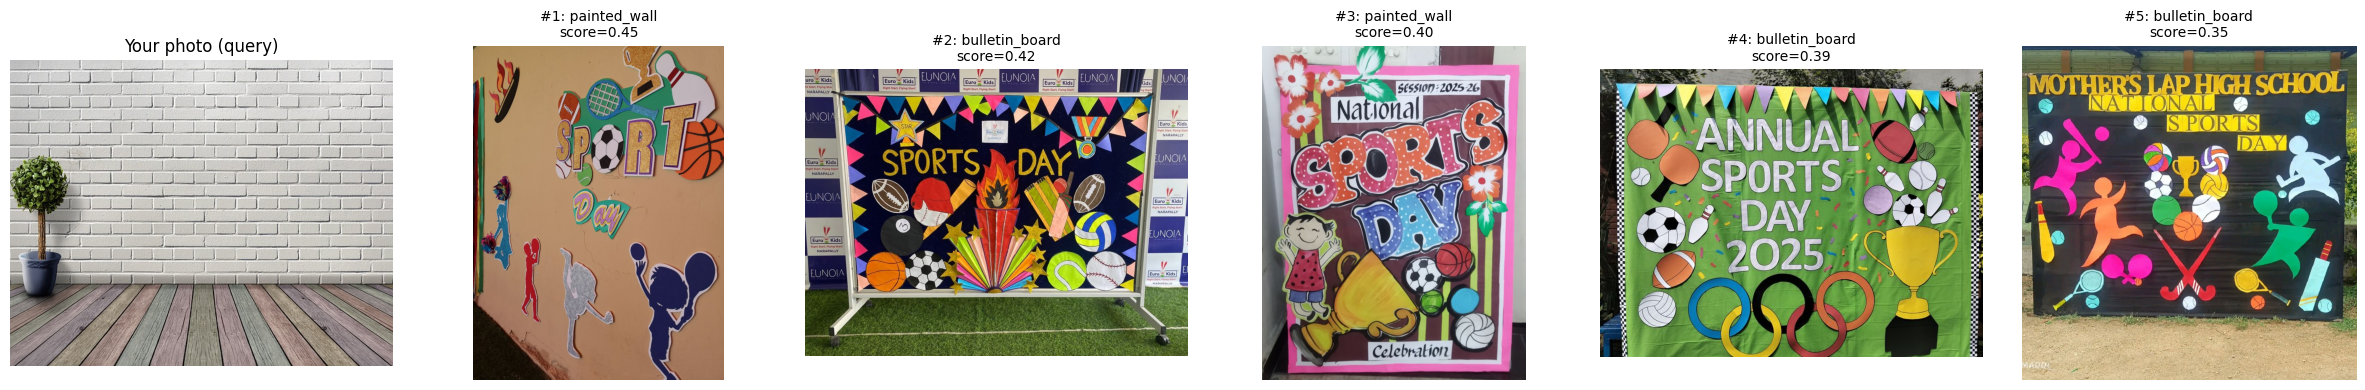

In [22]:
# ============================================================
# 8. INTERACTIVE RECOMMENDATION -- real user input + plan + visual output
# ============================================================

from google.colab import files
import matplotlib.pyplot as plt
from PIL import Image as PILImage


def show_reference_images(query_image_path, recommendations_df, top_k=5):
    fig, axes = plt.subplots(1, top_k + 1, figsize=(4 * (top_k + 1), 4))

    with PILImage.open(query_image_path) as img:
        axes[0].imshow(img.convert("RGB"))
    axes[0].set_title("Your photo (query)")
    axes[0].axis("off")

    for i, (_, row) in enumerate(recommendations_df.iterrows()):
        matches = glob.glob(os.path.join(RAW_IMAGES_FOLDER, row["image_id"] + ".*"))
        rec_path = matches[0] if matches else None
        if rec_path:
            with PILImage.open(rec_path) as img:
                axes[i + 1].imshow(img.convert("RGB"))
        title = "#{}: {}\nscore={:.2f}".format(i + 1, row["wall_type"], row["similarity_score"])
        axes[i + 1].set_title(title, fontsize=10)
        axes[i + 1].axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_FOLDER, "latest_recommendation_visual.png"), dpi=150)
    plt.show()


def get_user_query():
    print("Upload a photo of the wall you want decoration ideas for:")
    uploaded = files.upload()
    uploaded_filename = next(iter(uploaded.keys()))
    uploaded_path = os.path.join("/content", uploaded_filename)
    event_text = input("\nDescribe the event (e.g. 'Pohela Boishakh celebration', 'cricket tournament'): ")
    return uploaded_path, event_text


# ---- Run the interactive flow ----
query_image_path, event_text = get_user_query()
plan, recommendations = generate_decoration_plan(query_image_path, event_text, top_k=5)
show_reference_images(query_image_path, recommendations, top_k=5)
